#  PersonaVerify: AI Fake Profile Detection System

**Tech Stack:** Python · Scikit-learn · Pandas · Matplotlib · Seaborn · Joblib  
**Models:** Logistic Regression · Decision Tree · Random Forest  
**Goal:** Detect whether a social media profile is **Fake or Real**, with confidence scoring and explainable AI.

##  Table of Contents
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Preprocessing
6. Model Training (Logistic Regression, Decision Tree, Random Forest)
7. Model Evaluation & Comparison
8. Explainable AI — Feature Importance
9. Save Best Model with Joblib
10. Prediction Function (Confidence Score + Explanation)


### 1.  Import Libraries

In [27]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import joblib
import os
os.makedirs('plots', exist_ok=True)

print(" All libraries imported successfully!")

 All libraries imported successfully!


### 2.  Load Dataset

In [28]:
#  Load train and test CSVs 
# Dataset: Instagram fake/real profile data
# Target column: 'fake'  →  1 = Fake profile,  0 = Real profile

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f"Train set shape : {train_df.shape}")
print(f"Test  set shape : {test_df.shape}")
print()
print(" First 5 rows of training data ")
train_df.head()

Train set shape : (576, 12)
Test  set shape : (120, 12)

 First 5 rows of training data 


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [29]:
#  Column Descriptions 
column_info = {
    'profile pic'          : 'Binary — 1 if user has a profile picture, else 0',
    'nums/length username' : 'Ratio of numeric chars to total username length',
    'fullname words'       : 'Number of words in the full name',
    'nums/length fullname' : 'Ratio of numeric chars in full name',
    'name==username'       : 'Binary — 1 if display name equals username',
    'description length'   : 'Character count of bio/description',
    'external URL'         : 'Binary — 1 if profile has an external URL',
    'private'              : 'Binary — 1 if account is private',
    '#posts'               : 'Total number of posts',
    '#followers'           : 'Number of followers',
    '#follows'             : 'Number of accounts the user follows',
    'fake'                 : 'TARGET — 1 = Fake, 0 = Real'
}

desc_df = pd.DataFrame(list(column_info.items()), columns=['Column', 'Description'])
print(desc_df.to_string(index=False))

              Column                                      Description
         profile pic Binary — 1 if user has a profile picture, else 0
nums/length username  Ratio of numeric chars to total username length
      fullname words                 Number of words in the full name
nums/length fullname              Ratio of numeric chars in full name
      name==username       Binary — 1 if display name equals username
  description length               Character count of bio/description
        external URL        Binary — 1 if profile has an external URL
             private                 Binary — 1 if account is private
              #posts                            Total number of posts
          #followers                              Number of followers
            #follows              Number of accounts the user follows
                fake                      TARGET — 1 = Fake, 0 = Real


In [30]:
print(" Data Types & Null Counts ")
print(train_df.info())
print()
print(" Missing Values ")
print(train_df.isnull().sum())

 Data Types & Null Counts 
<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB
None

 Missing Values 
profile pic             0
nums/length username    0
fullname words          0
nums/length 

### 3.  Exploratory Data Analysis (EDA)

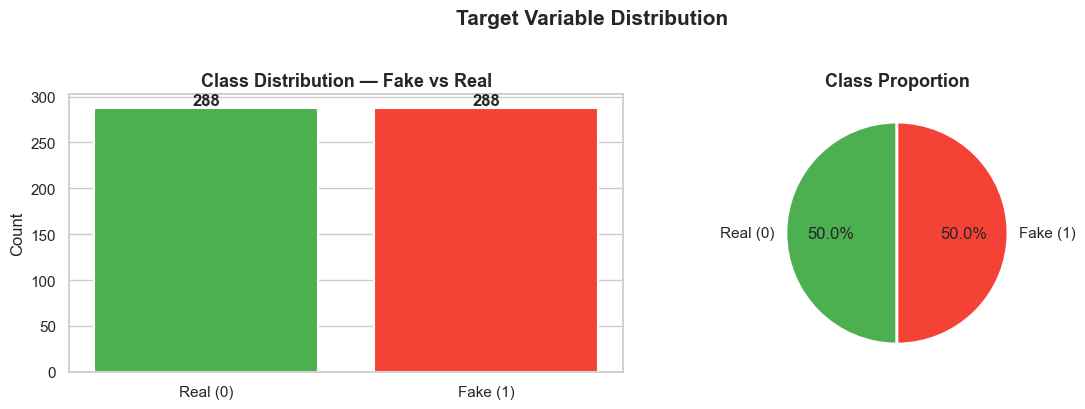

Dataset is perfectly balanced — 50% Fake, 50% Real


In [31]:
#  Target Class Distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train_df['fake'].value_counts()
labels = ['Real (0)', 'Fake (1)']
colors = ['#4CAF50', '#F44336']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — Fake vs Real', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset is perfectly balanced — 50% Fake, 50% Real")

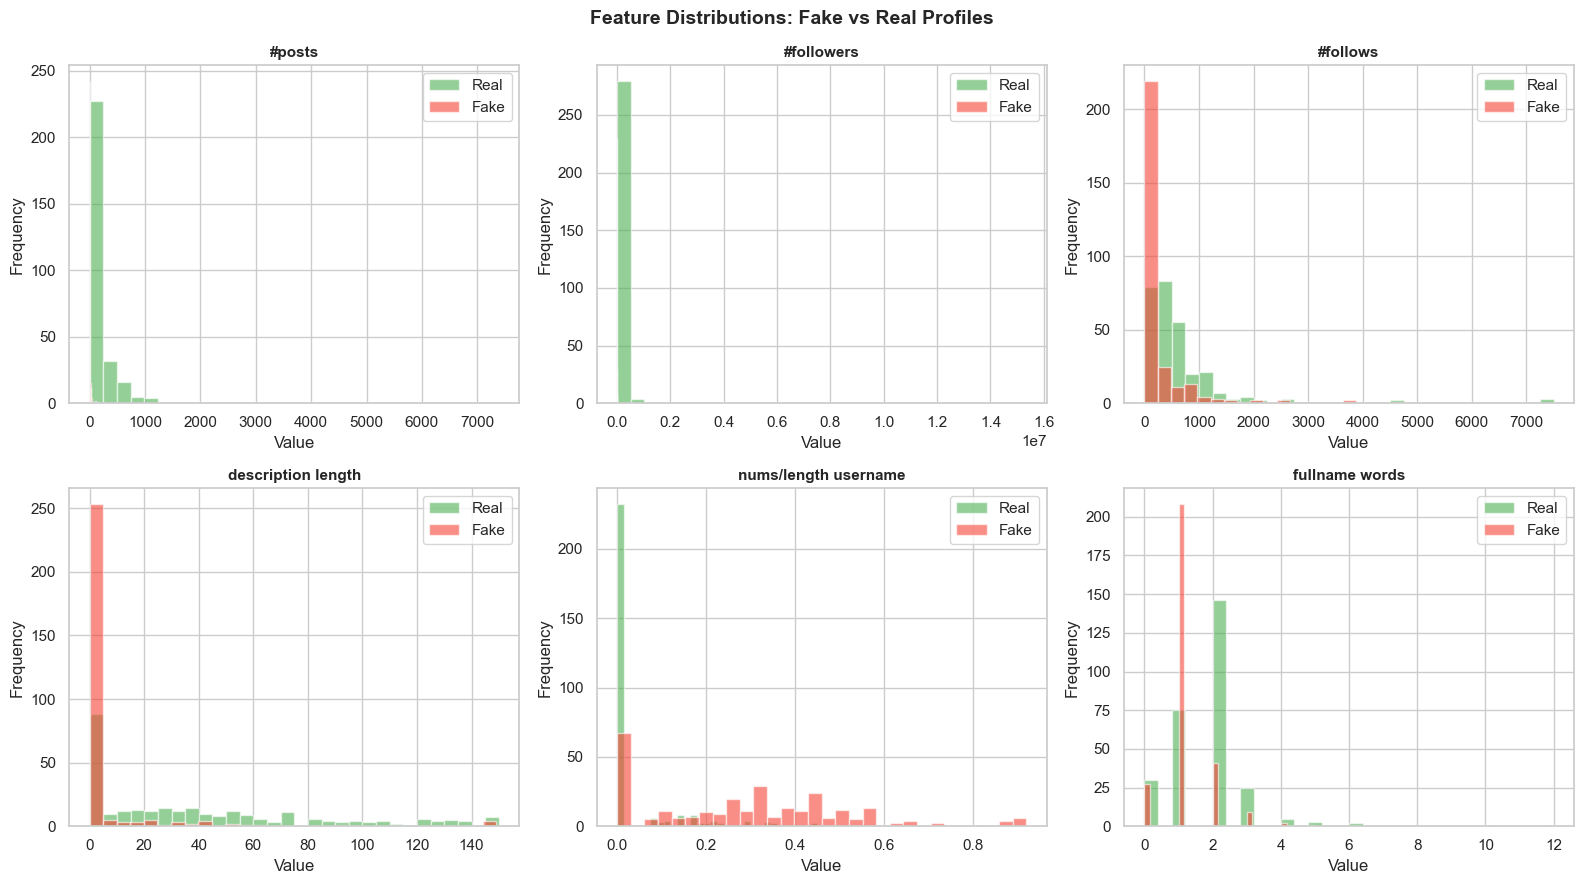

In [32]:
#  Feature Distributions: Fake vs Real 
numeric_cols = ['#posts', '#followers', '#follows', 'description length',
                'nums/length username', 'fullname words']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    real_vals = train_df[train_df['fake'] == 0][col]
    fake_vals = train_df[train_df['fake'] == 1][col]
    axes[i].hist(real_vals, bins=30, alpha=0.6, color='#4CAF50', label='Real', edgecolor='white')
    axes[i].hist(fake_vals, bins=30, alpha=0.6, color='#F44336', label='Fake', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions: Fake vs Real Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

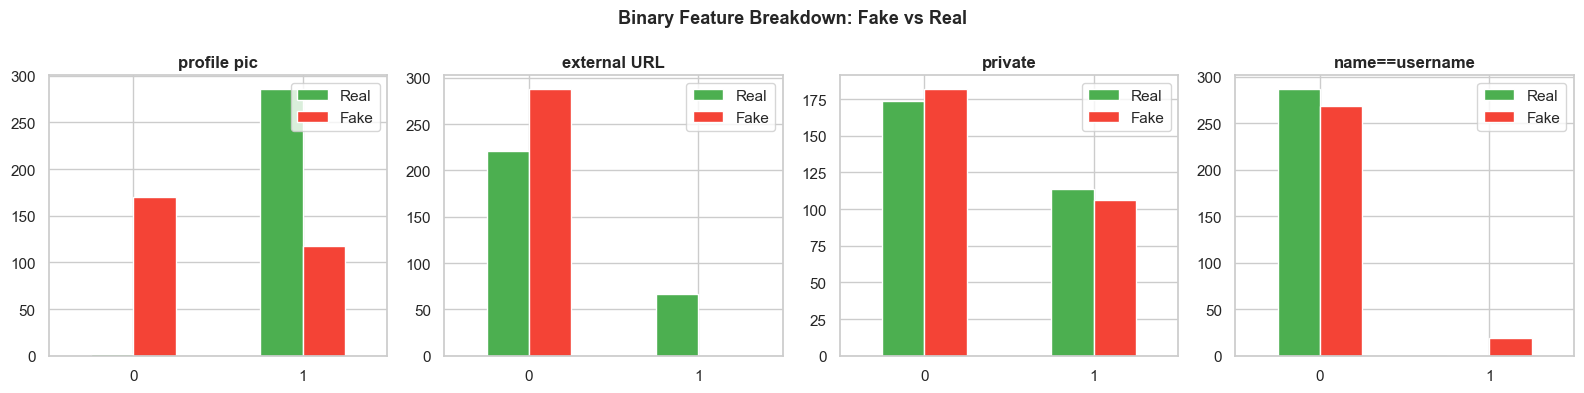

In [33]:
#  Binary Feature Analysis 
binary_cols = ['profile pic', 'external URL', 'private', 'name==username']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(binary_cols):
    grouped = train_df.groupby([col, 'fake']).size().unstack(fill_value=0)
    grouped.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
                 edgecolor='white', rot=0)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['Real', 'Fake'], loc='upper right')

plt.suptitle('Binary Feature Breakdown: Fake vs Real', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot_binary_features.png', dpi=150, bbox_inches='tight')
plt.show()

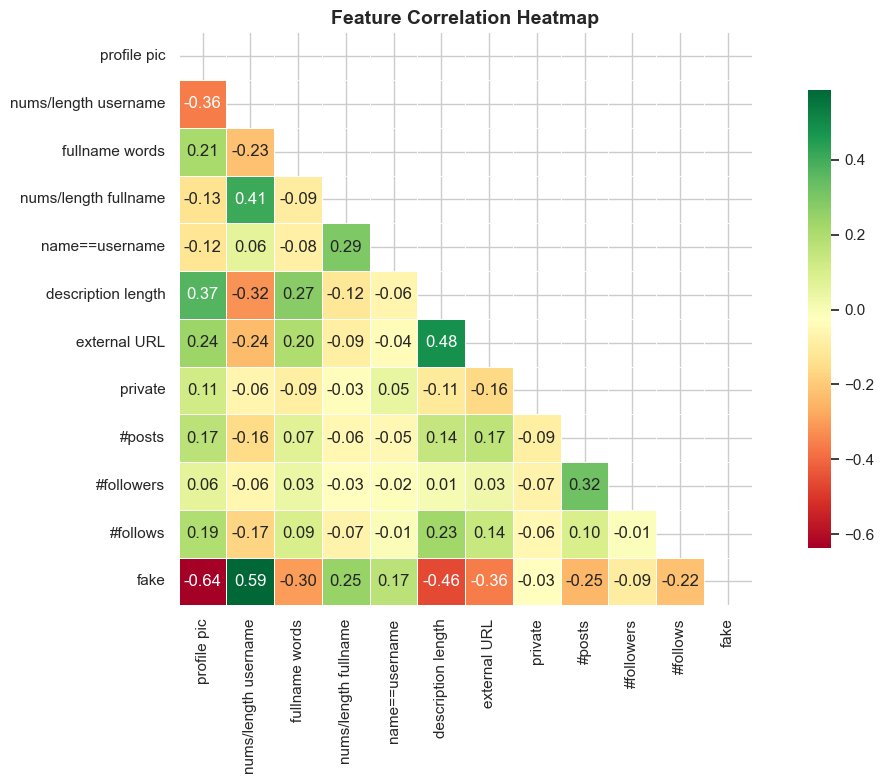

Correlation of features with target 'fake':
fake                    1.000000
nums/length username    0.587687
nums/length fullname    0.246782
name==username          0.170695
private                -0.028586
#followers             -0.093689
#follows               -0.224835
#posts                 -0.245355
fullname words         -0.298793
external URL           -0.362809
description length     -0.460825
profile pic            -0.637315


In [34]:
plt.figure(figsize=(12, 8))
corr = train_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation of features with target 'fake':")
print(corr['fake'].sort_values(ascending=False).to_string())

### 4.  Feature Engineering

We create **8+ engineered features** to improve model precision:
- `followers_following_ratio` — Low ratio = suspicious (following many but few follow back)
- `engagement_proxy` — Posts relative to followers
- `has_bio` — Binary flag for bio presence
- `is_active` — Has at least one post
- `follower_class` — Categorized follower count bucket


In [35]:
def engineer_features(df):
    """
    Applies feature engineering to the input DataFrame.
    Returns a new DataFrame with additional derived features.
    """
    df = df.copy()

    #  Feature 1: Followers / Following ratio 
    # A real user typically has a balanced or higher follower count.
    # Fake accounts often follow thousands but have few followers.
    df['followers_following_ratio'] = df['#followers'] / (df['#follows'] + 1)  # +1 to avoid /0

    #  Feature 2: Engagement proxy (posts per follower) 
    # Active, real accounts tend to post regularly relative to their follower base.
    df['post_per_follower'] = df['#posts'] / (df['#followers'] + 1)

    #  Feature 3: Has bio (binary) 
    df['has_bio'] = (df['description length'] > 0).astype(int)

    #  Feature 4: Is active (has at least 1 post) 
    df['is_active'] = (df['#posts'] > 0).astype(int)

    #  Feature 5: Log-transformed follower count 
    df['log_followers'] = np.log1p(df['#followers'])

    #  Feature 6: Log-transformed following count 
    df['log_follows'] = np.log1p(df['#follows'])

    #  Feature 7: Log-transformed post count 
    df['log_posts'] = np.log1p(df['#posts'])

    #  Feature 8: Username looks spammy (high numeric ratio) 
    df['spammy_username'] = (df['nums/length username'] > 0.3).astype(int)

    #  Feature 9: No profile picture AND no bio (double red flag) 
    df['no_pic_no_bio'] = ((df['profile pic'] == 0) & (df['description length'] == 0)).astype(int)

    return df


train_eng = engineer_features(train_df)
test_eng  = engineer_features(test_df)

print(f"Original features  : {train_df.shape[1] - 1}")   # exclude target
print(f"After engineering  : {train_eng.shape[1] - 1}")
print()
print("New columns added:")
new_cols = [c for c in train_eng.columns if c not in train_df.columns]
for c in new_cols:
    print(f"   {c}")

Original features  : 11
After engineering  : 20

New columns added:
   followers_following_ratio
   post_per_follower
   has_bio
   is_active
   log_followers
   log_follows
   log_posts
   spammy_username
   no_pic_no_bio


### 5.  Data Preprocessing

In [36]:
#  Separate Features and Target 
TARGET = 'fake'

X_train_raw = train_eng.drop(columns=[TARGET])
y_train      = train_eng[TARGET]

X_test_raw  = test_eng.drop(columns=[TARGET])
y_test       = test_eng[TARGET]

FEATURE_NAMES = X_train_raw.columns.tolist()
print(f"Training samples : {X_train_raw.shape[0]}")
print(f"Test     samples : {X_test_raw.shape[0]}")
print(f"Total features   : {len(FEATURE_NAMES)}")
print()
print("Feature list:", FEATURE_NAMES)

Training samples : 576
Test     samples : 120
Total features   : 20

Feature list: ['profile pic', 'nums/length username', 'fullname words', 'nums/length fullname', 'name==username', 'description length', 'external URL', 'private', '#posts', '#followers', '#follows', 'followers_following_ratio', 'post_per_follower', 'has_bio', 'is_active', 'log_followers', 'log_follows', 'log_posts', 'spammy_username', 'no_pic_no_bio']


In [37]:
#  Scale Features using StandardScaler 
# StandardScaler: transforms each feature to mean=0, std=1.
# Required for Logistic Regression (distance-based), good practice for all.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)   # fit on train only!
X_test_scaled  = scaler.transform(X_test_raw)         # transform test using train's stats

print(" Features scaled (mean=0, std=1)")
print(f"   X_train: {X_train_scaled.shape}")
print(f"   X_test : {X_test_scaled.shape}")

 Features scaled (mean=0, std=1)
   X_train: (576, 20)
   X_test : (120, 20)


### 6.  Model Training
We train **3 models** and compare them:
1. **Logistic Regression** — Simple, interpretable baseline
2. **Decision Tree** — Non-linear, rule-based
3. **Random Forest** — Ensemble, best performance expected

In [38]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,       # ensure convergence
        C=1.0,               # regularization strength (default)
        solver='lbfgs',
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,          # prevent overfitting
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,    # 200 trees for stability
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1            # use all CPU cores
    )
}

print("Models configured:")
for name in models:
    print(f"   {name}")

Models configured:
   Logistic Regression
   Decision Tree
   Random Forest


In [39]:
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    # Predict
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of 'Fake'

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cv   = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec * 100, 2),
        'F1-Score' : round(f1 * 100, 2),
        'AUC-ROC'  : round(auc * 100, 2),
        'CV Mean'  : round(cv.mean() * 100, 2),
        'CV Std'   : round(cv.std() * 100, 2),
        'y_pred'   : y_pred,
        'y_proba'  : y_proba
    }

    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print(f"  AUC-ROC   : {auc*100:.2f}%")
    print(f"  CV Score  : {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%")
    print()
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

print("\n All 3 models trained successfully!")


  Training: Logistic Regression
  Accuracy  : 93.33%
  Precision : 90.62%
  Recall    : 96.67%
  F1-Score  : 93.55%
  AUC-ROC   : 98.33%
  CV Score  : 93.39% ± 5.00%

              precision    recall  f1-score   support

        Real       0.96      0.90      0.93        60
        Fake       0.91      0.97      0.94        60

    accuracy                           0.93       120
   macro avg       0.94      0.93      0.93       120
weighted avg       0.94      0.93      0.93       120


  Training: Decision Tree
  Accuracy  : 85.83%
  Precision : 85.25%
  Recall    : 86.67%
  F1-Score  : 85.95%
  AUC-ROC   : 89.29%
  CV Score  : 91.14% ± 5.18%

              precision    recall  f1-score   support

        Real       0.86      0.85      0.86        60
        Fake       0.85      0.87      0.86        60

    accuracy                           0.86       120
   macro avg       0.86      0.86      0.86       120
weighted avg       0.86      0.86      0.86       120


  Training: Ran

### 7.  Model Evaluation & Comparison

In [40]:
summary = pd.DataFrame({
    name: {
        'Accuracy (%)' : r['Accuracy'],
        'Precision (%)': r['Precision'],
        'Recall (%)'   : r['Recall'],
        'F1-Score (%)'  : r['F1-Score'],
        'AUC-ROC (%)'  : r['AUC-ROC'],
        'CV Mean (%)'  : r['CV Mean'],
    }
    for name, r in results.items()
}).T

print("\n Model Performance Summary")
print(summary.to_string())
print()
best_model_name = summary['Accuracy (%)'].idxmax()
print(f" Best Model by Accuracy: {best_model_name} ({summary.loc[best_model_name, 'Accuracy (%)']}%)")


 Model Performance Summary
                     Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC-ROC (%)  CV Mean (%)
Logistic Regression         93.33          90.62       96.67         93.55        98.33        93.39
Decision Tree               85.83          85.25       86.67         85.95        89.29        91.14
Random Forest               93.33          90.62       96.67         93.55        99.36        93.92

 Best Model by Accuracy: Logistic Regression (93.33%)


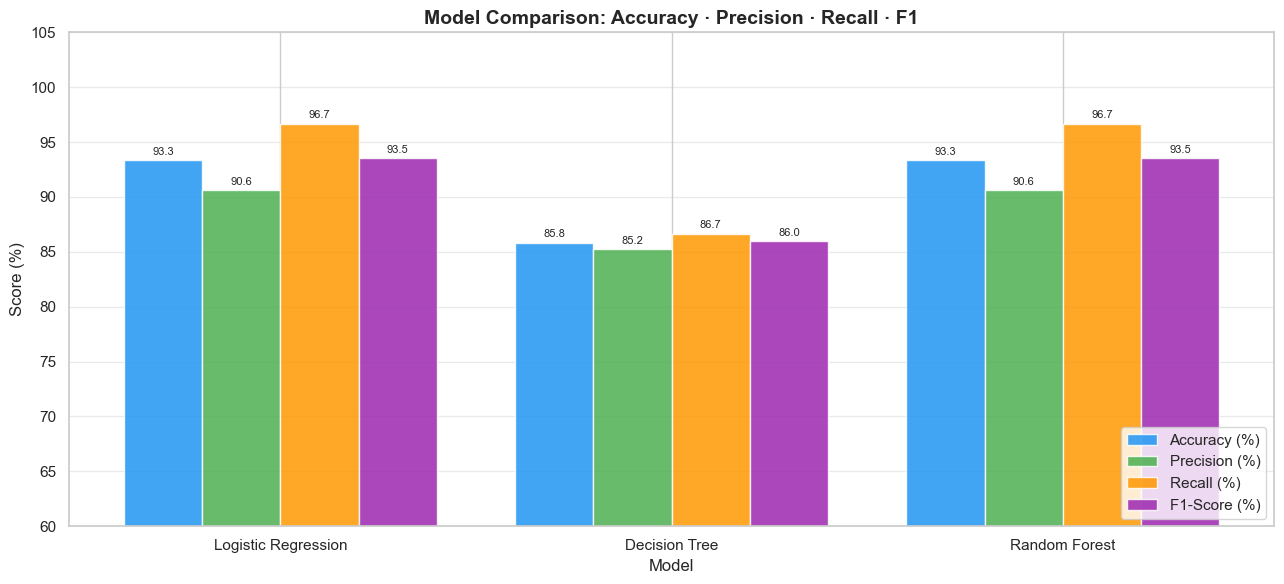

In [41]:
#  Bar Chart: Model Comparison 
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.2
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metrics):
    vals = [summary.loc[m, metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=colors_bar[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison: Accuracy · Precision · Recall · F1', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(60, 105)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plots/plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

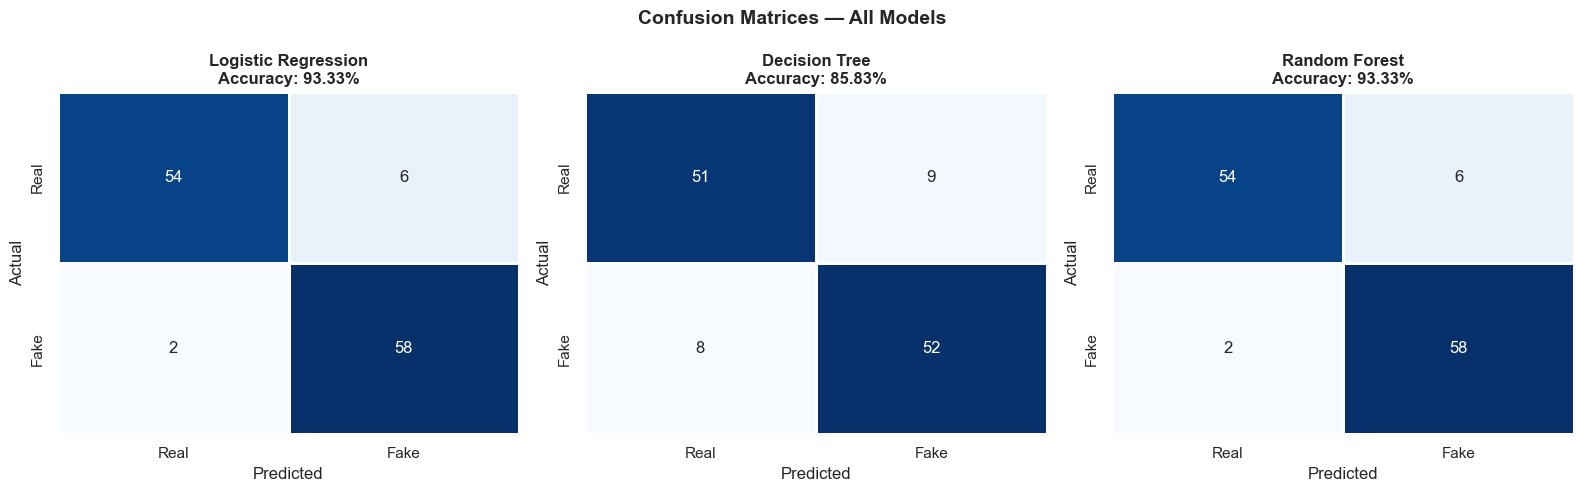

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(f'{name}\nAccuracy: {r["Accuracy"]}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

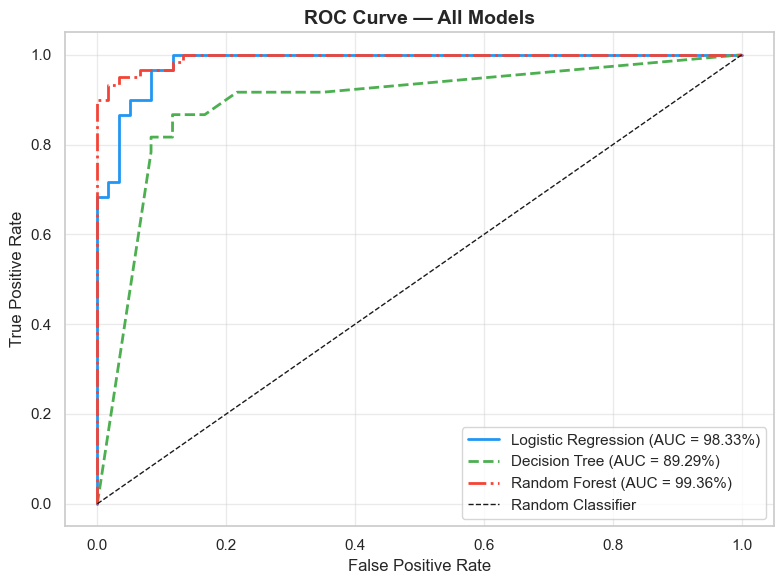

In [43]:
plt.figure(figsize=(8, 6))
line_styles = ['-', '--', '-.']
roc_colors  = ['#2196F3', '#4CAF50', '#F44336']

for (name, r), ls, col in zip(results.items(), line_styles, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, ls, lw=2, color=col,
             label=f'{name} (AUC = {r["AUC-ROC"]}%)')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('plots/plot_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.  Explainable AI — Feature Importance (Random Forest)

In [44]:
#  Random Forest Feature Importances 
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(" Feature Importance (Random Forest):")
print(fi_df.to_string(index=False))

 Feature Importance (Random Forest):
                  Feature  Importance
            log_followers    0.171302
               #followers    0.148926
                log_posts    0.122643
                   #posts    0.090419
followers_following_ratio    0.082864
     nums/length username    0.077316
              profile pic    0.058993
            no_pic_no_bio    0.046511
       description length    0.041907
                  has_bio    0.027583
        post_per_follower    0.024615
                 #follows    0.023996
          spammy_username    0.022676
              log_follows    0.020259
           fullname words    0.015966
                is_active    0.015731
                  private    0.004194
     nums/length fullname    0.002739
             external URL    0.000912
           name==username    0.000446


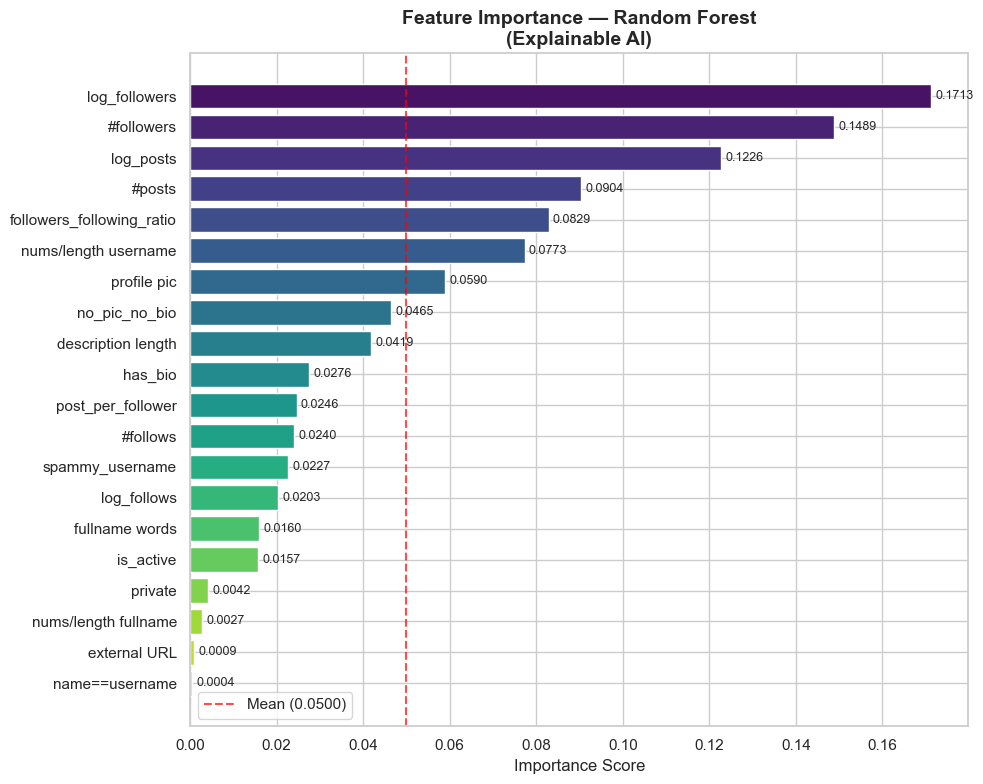


 Top 5 most influential features:
   1. log_followers  (0.1713)
   2. #followers  (0.1489)
   3. log_posts  (0.1226)
   4. #posts  (0.0904)
   5. followers_following_ratio  (0.0829)


In [45]:
#  Horizontal Bar Chart: Feature Importance 
palette = sns.color_palette('viridis', len(fi_df))

plt.figure(figsize=(10, 8))
bars = plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
                color=palette[::-1], edgecolor='white')

for bar, imp in zip(bars, fi_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{imp:.4f}', va='center', fontsize=9)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n(Explainable AI)', fontsize=14, fontweight='bold')
plt.axvline(x=fi_df['Importance'].mean(), color='red', linestyle='--',
            alpha=0.7, label=f'Mean ({fi_df["Importance"].mean():.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('plots/plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Top 5 most influential features:")
for i, row in fi_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']}  ({row['Importance']:.4f})")

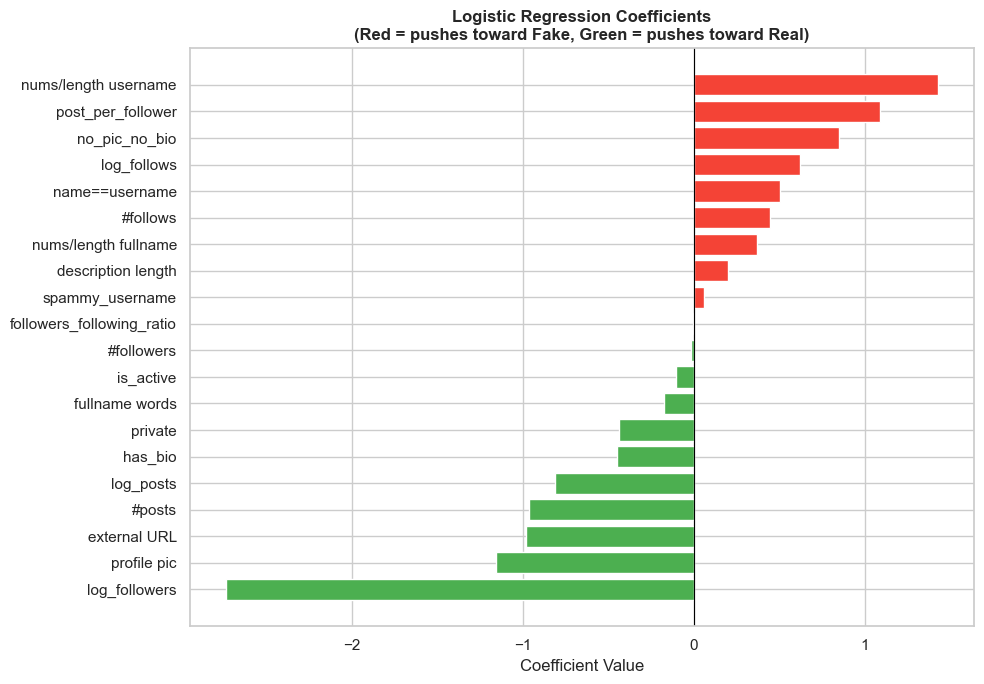

In [46]:
# LR coefficients tell us the direction (positive = more fake) and magnitude.
lr_model  = trained_models['Logistic Regression']
coefs     = lr_model.coef_[0]
coef_df   = pd.DataFrame({'Feature': FEATURE_NAMES, 'Coefficient': coefs})\
              .sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 7))
colors_coef = ['#F44336' if c > 0 else '#4CAF50' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
         color=colors_coef[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression Coefficients\n(Red = pushes toward Fake, Green = pushes toward Real)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.  Save Best Model with Joblib

In [47]:
os.makedirs('ml_model', exist_ok=True)

#  Select best model (highest accuracy) 
best_model_name = summary['Accuracy (%)'].idxmax()
best_model      = trained_models[best_model_name]
best_accuracy   = summary.loc[best_model_name, 'Accuracy (%)']

print(f" Best Model  : {best_model_name}")
print(f"   Accuracy   : {best_accuracy}%")

#  Save model 
joblib.dump(best_model, 'ml_model/fake_profile_model.pkl')
print(" Model saved → ml_model/fake_profile_model.pkl")

#  Save scaler 
joblib.dump(scaler, 'ml_model/scaler.pkl')
print(" Scaler saved → ml_model/scaler.pkl")

#  Save feature names 
joblib.dump(FEATURE_NAMES, 'ml_model/feature_names.pkl')
print(" Feature names saved → ml_model/feature_names.pkl")

#  Save feature importances (for XAI in API) 
joblib.dump(fi_df, 'ml_model/feature_importances.pkl')
print(" Feature importances saved → ml_model/feature_importances.pkl")

#  Save all 3 trained models 
for name, mdl in trained_models.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(mdl, f'ml_model/{fname}.pkl')
    print(f" Saved → ml_model/{fname}.pkl")

 Best Model  : Logistic Regression
   Accuracy   : 93.33%
 Model saved → ml_model/fake_profile_model.pkl
 Scaler saved → ml_model/scaler.pkl
 Feature names saved → ml_model/feature_names.pkl
 Feature importances saved → ml_model/feature_importances.pkl
 Saved → ml_model/logistic_regression.pkl
 Saved → ml_model/decision_tree.pkl
 Saved → ml_model/random_forest.pkl


In [48]:
#  Verify saved files 
saved = os.listdir('ml_model')
print(" Files in ml_model/:")
for f in sorted(saved):
    size = os.path.getsize(f'ml_model/{f}') / 1024
    print(f"   {f:45s}  ({size:.1f} KB)")

#  Quick smoke-test: reload & predict 
loaded_model  = joblib.load('ml_model/fake_profile_model.pkl')
loaded_scaler = joblib.load('ml_model/scaler.pkl')
test_pred = loaded_model.predict(loaded_scaler.transform(X_test_raw[:5]))
print()
print(" Smoke test — first 5 predictions:")
print("  Predicted:", ['Fake' if p else 'Real' for p in test_pred])
print("  Actual   :", ['Fake' if p else 'Real' for p in y_test[:5].values])

 Files in ml_model/:
   decision_tree.pkl                              (4.8 KB)
   fake_profile_model.pkl                         (1.0 KB)
   feature_importances.pkl                        (1.7 KB)
   feature_names.pkl                              (0.3 KB)
   logistic_regression.pkl                        (1.0 KB)
   random_forest.pkl                              (1043.3 KB)
   scaler.pkl                                     (1.6 KB)

 Smoke test — first 5 predictions:
  Predicted: ['Fake', 'Real', 'Real', 'Real', 'Fake']
  Actual   : ['Real', 'Real', 'Real', 'Real', 'Real']


### 10.  Prediction Function with Confidence Score & Explanation

In [49]:
def predict_profile(profile_data: dict, model=None, scaler=None, fi_df=None, top_n=5):
    """
    Predict whether a social media profile is FAKE or REAL.

    Parameters
    ----------
    profile_data : dict
        Raw profile features (same keys as original dataset).
    model, scaler, fi_df : loaded joblib objects
    top_n : int — number of top features to show in explanation

    Returns
    -------
    dict with prediction, confidence_score, and top_features (XAI)
    """
    if model is None:
        model  = joblib.load('ml_model/fake_profile_model.pkl')
    if scaler is None:
        scaler = joblib.load('ml_model/scaler.pkl')
    if fi_df is None:
        fi_df  = joblib.load('ml_model/feature_importances.pkl')

    df_input = pd.DataFrame([profile_data])

    # Step 2: Apply same feature engineering
    df_eng = engineer_features(df_input)

    # Remove target column if accidentally present
    if 'fake' in df_eng.columns:
        df_eng = df_eng.drop(columns=['fake'])

    X_scaled = scaler.transform(df_eng)

    # Step 4: Predict
    prediction    = model.predict(X_scaled)[0]
    probabilities = model.predict_proba(X_scaled)[0]  # [P(Real), P(Fake)]
    confidence    = round(float(probabilities[1]), 4)  # probability of being Fake

    # Step 5: Get top contributing features (XAI)
    top_features = fi_df.head(top_n)['Feature'].tolist()

    # Interpret each top feature for human-readable explanation
    feature_insights = []
    feature_vals = df_eng.iloc[0]

    insights_map = {
        'profile pic'             : (lambda v: "No profile picture" if v == 0 else "Has profile picture"),
        'nums/length username'    : (lambda v: f"Username is {v*100:.0f}% numeric chars"),
        'description length'      : (lambda v: "Empty bio" if v == 0 else f"Bio length: {v} chars"),
        '#followers'              : (lambda v: f"{int(v)} followers"),
        '#follows'                : (lambda v: f"Following {int(v)} accounts"),
        '#posts'                  : (lambda v: f"{int(v)} posts"),
        'followers_following_ratio': (lambda v: f"Follower/following ratio: {v:.2f}"),
        'log_followers'           : (lambda v: f"Log followers: {v:.2f}"),
        'log_follows'             : (lambda v: f"Log follows: {v:.2f}"),
        'post_per_follower'       : (lambda v: f"Posts per follower: {v:.4f}"),
        'has_bio'                 : (lambda v: "Has bio" if v == 1 else "No bio"),
        'is_active'               : (lambda v: "Active account" if v == 1 else "No posts (inactive)"),
        'no_pic_no_bio'           : (lambda v: " No profile pic AND no bio" if v == 1 else "Has pic or bio"),
        'spammy_username'         : (lambda v: " Spammy numeric username" if v == 1 else "Clean username"),
    }

    for feat in top_features:
        if feat in feature_vals and feat in insights_map:
            val     = feature_vals[feat]
            insight = insights_map[feat](val)
            feature_insights.append(insight)
        else:
            feature_insights.append(feat)

    return {
        'prediction'      : 'Fake' if prediction == 1 else 'Real',
        'confidence_score': confidence,
        'confidence_pct'  : f"{confidence * 100:.1f}%",
        'top_features'    : top_features,
        'feature_insights': feature_insights,
    }


print(" predict_profile() function defined")

 predict_profile() function defined


In [50]:
#  Demo: Predict a FAKE profile 
fake_profile_example = {
    'profile pic'         : 0,     # no profile picture
    'nums/length username': 0.75,  # username is 75% numbers (e.g. 'user19283746')
    'fullname words'      : 1,
    'nums/length fullname': 0,
    'name==username'      : 1,     # display name = username (suspicious)
    'description length'  : 0,     # no bio
    'external URL'        : 0,
    'private'             : 0,
    '#posts'              : 2,
    '#followers'          : 18,
    '#follows'            : 3500,  # follows many but few follow back
}

result = predict_profile(fake_profile_example)

print(" PREDICTION RESULT")
print("=" * 45)
print(f"  Prediction       : {' ' + result['prediction'] if result['prediction'] == 'Fake' else ' ' + result['prediction']}")
print(f"  Confidence Score : {result['confidence_pct']} (fake probability)")
print()
print("   Top Features Driving This Prediction:")
for i, insight in enumerate(result['feature_insights'], 1):
    print(f"     {i}. {insight}")

 PREDICTION RESULT
  Prediction       :  Fake
  Confidence Score : 100.0% (fake probability)

   Top Features Driving This Prediction:
     1. Log followers: 2.94
     2. 18 followers
     3. log_posts
     4. 2 posts
     5. Follower/following ratio: 0.01


In [51]:
#  Demo: Predict a REAL profile 
real_profile_example = {
    'profile pic'         : 1,     # has profile picture
    'nums/length username': 0.0,   # clean username (e.g. 'johndoe')
    'fullname words'      : 2,     # 'John Doe'
    'nums/length fullname': 0,
    'name==username'      : 0,
    'description length'  : 85,    # has a bio
    'external URL'        : 1,     # has website link
    'private'             : 0,
    '#posts'              : 142,
    '#followers'          : 980,
    '#follows'            : 420,
}

result2 = predict_profile(real_profile_example)

print(" PREDICTION RESULT")
print("=" * 45)
print(f"  Prediction       : {' ' + result2['prediction'] if result2['prediction'] == 'Fake' else ' ' + result2['prediction']}")
print(f"  Confidence Score : {result2['confidence_pct']} (fake probability)")
print()
print("   Top Features Driving This Prediction:")
for i, insight in enumerate(result2['feature_insights'], 1):
    print(f"     {i}. {insight}")

 PREDICTION RESULT
  Prediction       :  Real
  Confidence Score : 0.1% (fake probability)

   Top Features Driving This Prediction:
     1. Log followers: 6.89
     2. 980 followers
     3. log_posts
     4. 142 posts
     5. Follower/following ratio: 2.33


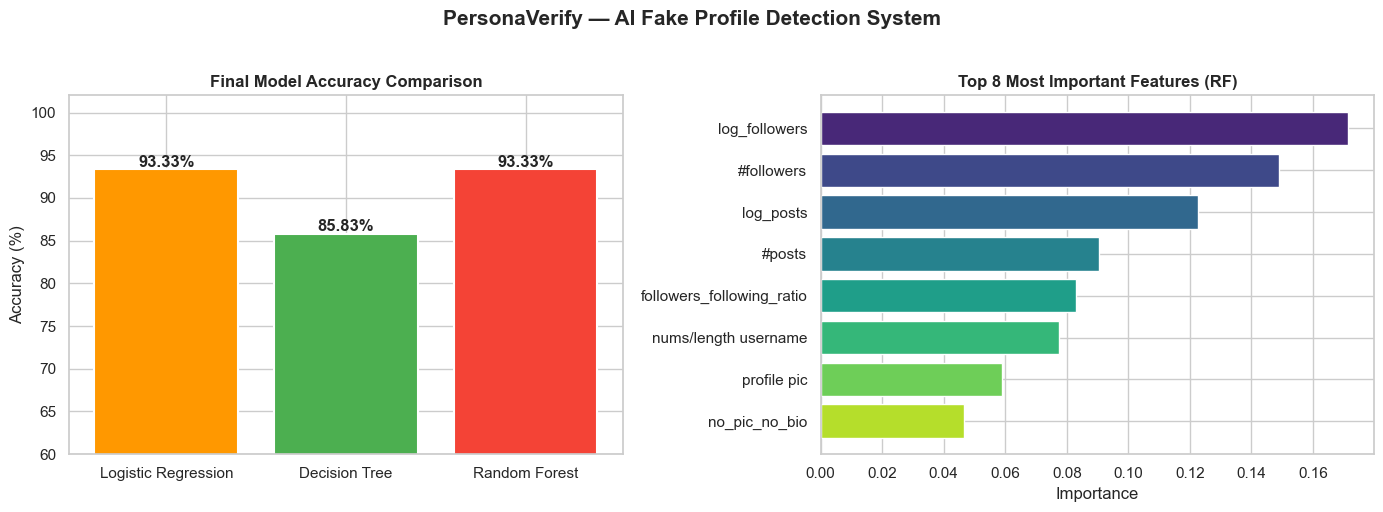


 Notebook complete!
   Best model  : Logistic Regression
   Accuracy    : 93.33%
   Precision   : 90.62%
   Recall      : 96.67%
   All files saved in ml_model/


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_vals   = [results[m]['Accuracy'] for m in model_names]
bar_colors = ['#FF9800', '#4CAF50', '#F44336']
bars = axes[0].bar(model_names, acc_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(60, 102)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Final Model Accuracy Comparison', fontweight='bold')
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontweight='bold', fontsize=12)

# Right: Top 8 features
top8 = fi_df.head(8)
axes[1].barh(top8['Feature'][::-1], top8['Importance'][::-1],
             color=sns.color_palette('viridis', 8)[::-1], edgecolor='white')
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 8 Most Important Features (RF)', fontweight='bold')

plt.suptitle('PersonaVerify — AI Fake Profile Detection System', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/plot_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(" Notebook complete!")
print(f"   Best model  : {best_model_name}")
print(f"   Accuracy    : {summary.loc[best_model_name, 'Accuracy (%)']}%")
print(f"   Precision   : {summary.loc[best_model_name, 'Precision (%)']}%")
print(f"   Recall      : {summary.loc[best_model_name, 'Recall (%)']}%")
print(f"   All files saved in ml_model/")